In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("adult.csv")
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
data.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [5]:
print(data.workclass.value_counts())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


In [6]:
data.workclass.replace({'?':'others'}, inplace= True)
print(data.workclass.value_counts())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
others               2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


C:\Users\AAA\AppData\Local\Temp\ipykernel_14216\823526077.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.workclass.replace({'?':'others'}, inplace= True)


In [7]:
data= data[data['workclass']!= 'Without-pay']
data= data[data['workclass']!= 'Never-worked']
print(data.workclass.value_counts())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
others               2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Name: count, dtype: int64


In [8]:
data.replace({'?':'others'}, inplace= True)
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,others,103497,Some-college,10,Never-married,others,Own-child,White,Female,0,0,30,United-States,<=50K


In [9]:
data.education.value_counts()

education
HS-grad         15768
Some-college    10873
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1809
Assoc-acdm       1599
10th             1387
7th-8th           952
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

In [10]:
data= data[data['education']!= 'Preschool']
data= data[data['education']!= '5th-6th']
data= data[data['education']!= '1st-4th']
print(data.education.value_counts())

education
HS-grad         15768
Some-college    10873
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1809
Assoc-acdm       1599
10th             1387
7th-8th           952
Prof-school       834
9th               756
12th              657
Doctorate         594
Name: count, dtype: int64


In [11]:
data.occupation.value_counts()

occupation
Prof-specialty       6165
Exec-managerial      6072
Craft-repair         6006
Adm-clerical         5591
Sales                5476
Other-service        4746
Machine-op-inspct    2877
others               2730
Transport-moving     2302
Handlers-cleaners    1980
Tech-support         1445
Farming-fishing      1380
Protective-serv       981
Priv-house-serv       206
Armed-Forces           15
Name: count, dtype: int64

In [12]:
data= data[data['occupation']!= 'Armed-Forces']
print(data.occupation.value_counts())

occupation
Prof-specialty       6165
Exec-managerial      6072
Craft-repair         6006
Adm-clerical         5591
Sales                5476
Other-service        4746
Machine-op-inspct    2877
others               2730
Transport-moving     2302
Handlers-cleaners    1980
Tech-support         1445
Farming-fishing      1380
Protective-serv       981
Priv-house-serv       206
Name: count, dtype: int64


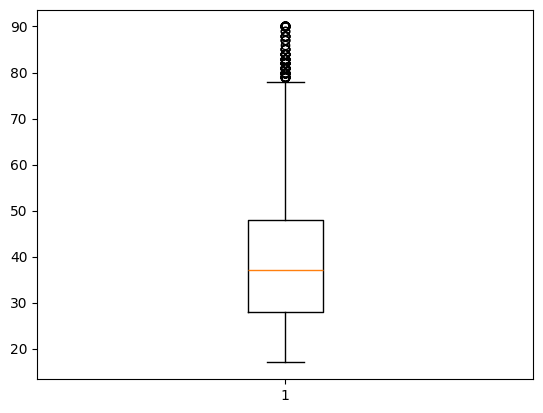

In [13]:
plt.boxplot(data['age'])
plt.show()

In [14]:
data= data[(data['age']<= 75) & (data['age']>= 17)]
data.shape

(47604, 15)

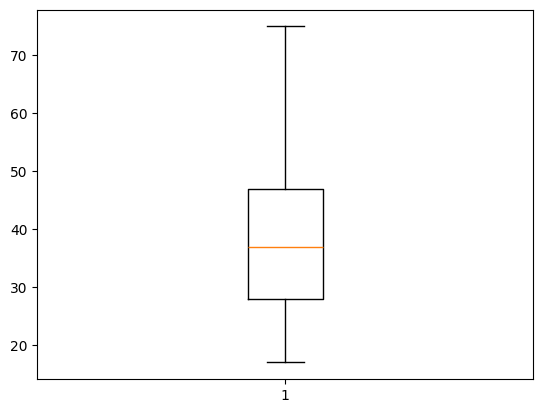

In [15]:
plt.boxplot(data['age'])
plt.show()

In [16]:
data.drop(columns= ['education'], inplace= True)
data.columns

Index(['age', 'workclass', 'fnlwgt', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [17]:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()
data['workclass']= encoder.fit_transform(data['workclass'])
data['marital-status']= encoder.fit_transform(data['marital-status'])
data['occupation']= encoder.fit_transform(data['occupation'])
data['relationship']= encoder.fit_transform(data['relationship'])
data['gender']= encoder.fit_transform(data['gender'])
data['race']= encoder.fit_transform(data['race'])
data['native-country']= encoder.fit_transform(data['native-country'])
data.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,226802,7,4,5,3,2,1,0,0,40,38,<=50K
1,38,2,89814,9,2,3,0,4,1,0,0,50,38,<=50K
2,28,1,336951,12,2,9,0,4,1,0,0,40,38,>50K
3,44,2,160323,10,2,5,0,2,1,7688,0,40,38,>50K
4,18,6,103497,10,4,13,3,4,0,0,0,30,38,<=50K


In [18]:
X= data.drop(columns=['income'])
y= data['income']

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()
X = scaler.fit_transform(X)
X

array([[0.13793103, 0.33333333, 0.14512876, ..., 0.        , 0.39795918,
        0.92682927],
       [0.36206897, 0.33333333, 0.05245126, ..., 0.        , 0.5       ,
        0.92682927],
       [0.18965517, 0.16666667, 0.21964867, ..., 0.        , 0.39795918,
        0.92682927],
       ...,
       [0.70689655, 0.33333333, 0.09446153, ..., 0.        , 0.39795918,
        0.92682927],
       [0.0862069 , 0.33333333, 0.12800425, ..., 0.        , 0.19387755,
        0.92682927],
       [0.60344828, 0.5       , 0.18648211, ..., 0.        , 0.39795918,
        0.92682927]])

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=23,stratify=y)

In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn=  KNeighborsClassifier()
knn.fit(X_train,y_train)
predict = knn.predict(X_test)
predict

array(['<=50K', '>50K', '<=50K', ..., '<=50K', '<=50K', '<=50K'],
      dtype=object)

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict)

0.8255435353429261